In [15]:
from dotenv import load_dotenv
import os
import langgraph.config as langgraph_config
load_dotenv()


True

In [16]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
from graph_states import LearnerProfileState

# 1. Mount serialization whitelisting
custom_serde = JsonPlusSerializer(allowed_msgpack_modules=[LearnerProfileState])

# 2. Open a pristine file connection pool
db_connection = sqlite3.connect("./skillforge_storage.db", check_same_thread=False)

# 3. Re-instantiate the persistent saver
db_checkpointer = SqliteSaver(conn=db_connection, serde=custom_serde)

# 4. Re-run setup to verify schema state
db_checkpointer.setup()
db_connection.commit()
print("💾 SQLite Checkpointer successfully re-hydrated from disk file!")




💾 SQLite Checkpointer successfully re-hydrated from disk file!


In [17]:
from typing import Any, Dict
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.errors import GraphInterrupt
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

In [18]:
from graph_states import InterviewSubgraphState, InterviewSummaryState, LearnerState, EvaluationState
from prompts import INTERVIEWER_PROMPT, SUMMARIZATION_SYSTEM_PROMPT

In [19]:
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
'''
model = ChatOllama(model="qwen2.5:7b", temperature=0,base_url="http://localhost:11434")
'''
model = ChatOpenAI(
    model=os.environ["AI_MODEL"],
    temperature=0.1     # Keep low for analytical consistency
)

eval_model = ChatOpenAI(
    model=os.environ["AI_JUDGE_MODEL"],
    temperature=0.1     # Keep low for analytical consistency
)

In [20]:
# LangGraph Concept: Subgraph State Reading — Dynamically analyzes runtime user interests and gaps to generate a single, progressively complex Socratic question without providing direct answers.

def QuestionGeneratorNode(state: InterviewSubgraphState) -> InterviewSubgraphState:

    # LangGraph Concept: Dynamically analyzes runtime user interests and gaps to generate a single, progressively complex Socratic question without providing direct answers.

    known_gap_info = state.known_gaps or []
    detected_gap_info = state.detected_gaps or []
    chat_history = state.interview_messages or []
    learner = state.learner_profile
    learner_interests = learner.interests or []




    system_prompt = INTERVIEWER_PROMPT.format(
        user_interest=learner_interests,
        known_gaps=known_gap_info,
        detected_gaps=detected_gap_info,
    )

    messages = [SystemMessage(content=system_prompt)] + chat_history
    response = model.invoke(messages)

    return {
        "interview_messages": [AIMessage(content=str(response.content))]
    }


In [21]:
from langgraph.types import interrupt

# LangGraph Concept: Inline Interruptions — Executes an inline interrupt() that freezes the graph engine to asynchronously capture user text responses from the notebook interface.
def follow_up_node(state: InterviewSubgraphState) -> Dict[str, Any]:
    #  Executes an inline interrupt() that freezes the graph engine to asynchronously capture user text responses from the notebook interface.

    user_input = interrupt("") # # Triggers a programmatic pause and broadcasts out of the graph. Kept blank as the cell box below will use unput to get users input

    cleaned_input = str(user_input).strip()
    question_asked = state.question_asked
    max_question = state.max_question
    next_question_count = question_asked + 1

    if cleaned_input.upper() in ["N", "NO", "EXIT", "DONE"] or next_question_count >= max_question:
        return {"question_asked": next_question_count, "subgraph_approval": "approved"}

    return {
        "interview_messages": [HumanMessage(content=cleaned_input)],
        "question_asked": next_question_count,
        "subgraph_approval": "pending"
    }


In [22]:
# LangGraph Concept: Subgraph State Output Mapping — Runs a single-turn structured extraction task at the subgraph's boundary to map the final chat summary and raw gaps up to the parent graph.
def summarisation_node(state: InterviewSubgraphState) -> Dict[str, Any]:
    # Runs a single-turn structured extraction task at the subgraph's boundary to map the final chat summary and raw gaps up to the parent graph.

    chat_history = state.interview_messages or []

    summary_model = model.with_structured_output(InterviewSummaryState)

    messages = [SystemMessage(content=SUMMARIZATION_SYSTEM_PROMPT)] + chat_history

    structured_response: InterviewSummaryState = summary_model.invoke(messages)

    return {
        "interview_summary": structured_response.interview_summary,
        "detected_gaps": structured_response.detected_gaps
    }


In [23]:
from prompts import EVALUATION_PROMPT

# LangGraph Concept: Conditional Edges & Dynamic Breakpoints — Functions as an LLM-as-a-Judge validation gate that triggers a mid-node dynamic breakpoint if the interview data confidence score drops below the safety threshold.
def evaluation_node(learner_state: LearnerState) -> LearnerState:
    # Functions as an LLM-as-a-Judge validation gate that triggers a mid-node dynamic breakpoint if the interview data confidence score drops below the safety threshold.

    known_gaps = learner_state.known_gaps or []
    detected_gaps = learner_state.detected_gaps
    interview_summary = learner_state.interview_summary



    evaluation_model = eval_model.with_structured_output(EvaluationState)

    formatted_prompt = EVALUATION_PROMPT.format(
        transcript_summary=interview_summary,
        known_gaps=known_gaps,
        detected_gaps=detected_gaps
    )



    messages = [SystemMessage(content=formatted_prompt)]
    evaluation_response: EvaluationState = evaluation_model.invoke(messages)

    if evaluation_response.confidence_score < 0.7:
        print(f"Low Confidence Detected ({evaluation_response.confidence_score}). Rest assured, this is not you..we may need further data or confirmation to proceed to allign you a for a perfect upliftment.")



        # Format the interactive question text dynamically based on the current gaps
        eval_interrupt_msg = (
            f"\n🤖 [SYSTEM NOTE] Observed Gaps: {detected_gaps}\n"
            f"Rationale: {evaluation_response.evaluation_rationale}\n"
            f"Would you like to proceed with this Learning Plan (YES), "
            f"or would you like us to further analyze your skills (NO)?"
        )

        # Set a flag in the state indicating we are pausing, then trigger the engine freeze
        # We pass the message text out so the notebook driver can display it
        interrupt(eval_interrupt_msg)

        # When execution hits interrupt(), it stops immediately.
        # To make sure the node knows it's a resume run next time, we store a 0.0 marker state.
        return {
            "gap_confidence_score": 0.0,
            "approval_status": "pending"
        }
    else:
        print(f"High Confidence Verified ({evaluation_response.confidence_score}). Advancing to Stage 5.")
        return {
            "gap_confidence_score": evaluation_response.confidence_score,
            "approval_status": "approved"
        }


In [24]:
interview_builder = StateGraph(InterviewSubgraphState)

# Register Subgraph Nodes
interview_builder.add_node("question_generator", QuestionGeneratorNode)
interview_builder.add_node("follow_up", follow_up_node)
interview_builder.add_node("summarisation", summarisation_node)

# Linear flow inside the subgraph
interview_builder.add_edge(START, "question_generator") # Subgraph starts at question generator
interview_builder.add_edge("question_generator", "follow_up")

def check_approval_status(state: InterviewSubgraphState) -> str:
    """Pure routing conditional check based on state attributes."""
    if state.subgraph_approval == "approved":
        return "finish"
    return "loop_back"

# FIX: Origin node must be "follow_up" because you renamed your node!
interview_builder.add_conditional_edges(
    "follow_up",
    check_approval_status,
    {
        "finish": "summarisation",
        "loop_back": "question_generator"
    }
)
interview_builder.add_edge("summarisation", END) # Subgraph MUST end at END

# Compile the Subgraph independently
# FIX: Since follow_up uses native interrupt(), remove compile-level interrupt_after!
memory = MemorySaver()
compiled_interview_subgraph = interview_builder.compile()


In [25]:
# LangGraph Concept: StateGraph Initialization — Logs session context and archives previous findings into a historical ledger to safely prepare a clean state configuration before entering the interview loop.

def parent_init_node(state: LearnerState) -> Dict[str, Any]:
    # Logs session context and archives previous findings into a historical ledger to safely prepare a clean state configuration before entering the interview loop.

    print(f"\n[Parent Gate] Bootstrapping SkillForge pipeline for user.")
    print(f"Current interests captured: {state.learner_profile.interests}")

    # Return empty dict for now; it simply acts as a clear visual anchor in our logs
    return {}

In [26]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

parent_builder = StateGraph(LearnerState)

# 1. Register Parent Nodes
parent_builder.add_node("parent_init", parent_init_node)
parent_builder.add_node("evaluation_node", evaluation_node)

# FIX: Register the subgraph with an explicit state channel mapping configuration.
# This forces the graph compiler to map parent properties down,
# allowing the Mermaid engine to visually explode the node internals under xray=1.
parent_builder.add_node(
    "interview_loop",
    compiled_interview_subgraph
)

# 2. Wire the Parent Graph Path
parent_builder.add_edge(START, "parent_init")
parent_builder.add_edge("parent_init", "interview_loop")
parent_builder.add_edge("interview_loop", "evaluation_node")

def check_parent_gate_status(state: LearnerState) -> str:
    if state.approval_status == "approved":
        return "finish"
    return "loop_back_to_interview"

parent_builder.add_conditional_edges(
    "evaluation_node",
    check_parent_gate_status,
    {
        "finish": END,
        "loop_back_to_interview": "interview_loop"
    }
)

# 3. Compile the Parent Graph

parent_graph = parent_builder.compile(checkpointer=db_checkpointer)

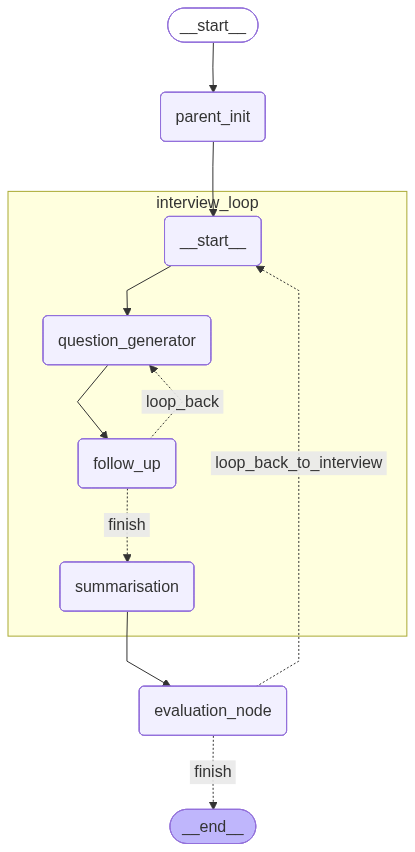

In [27]:

# Display
from IPython.display import Image, display
display(Image(parent_graph.get_graph(xray=1).draw_mermaid_png()))


In [28]:
from skillforge_ui import build_skillforge_ui
build_skillforge_ui(parent_graph)